In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.interpolate import interp1d
from tqdm import tqdm

In [26]:
df = pd.read_csv("paired_simulation_labels_combined.csv")

In [27]:
# ==========================================
# 1. Fast Loader
# ==========================================

def load_corrected_lightcurve(folder_path):
    """Robust file loader that safely ignores text headers."""
    dat_files = glob.glob(os.path.join(folder_path, "*_driftcorrected.dat"))
    if not dat_files:
        dat_files = glob.glob(os.path.join(folder_path, "*.dat"))
        
    if dat_files:
        data_rows = []
        with open(dat_files[0], "r") as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                try:
                    data_rows.append([float(p) for p in parts])
                except ValueError:
                    # Silently ignore header strings
                    continue
        data = np.asarray(data_rows, dtype=float)
        if data.ndim == 2 and data.shape[1] >= 2:
            return data[:, 0], data[:, 1]

    return None, None


In [28]:
# ==========================================
# 2. Pre-baking and Plotting Routine
# ==========================================

def build_prebaked_dataset(df, max_length=6000, save_path="prebaked_lightcurves.pt", plot_samples=3):
    print("Initializing pre-baking process...")
    
    event_map = {"neither": 0, "flare": 1, "transit": 2, "both": 3}
    
    # Storage arrays
    all_fluxes = []
    all_labels = []
    all_ids = []
    plot_data = [] # To store a few examples for visualization

    # Standard sequential loop is fast enough here since we are only doing array math, 
    # not full BLS periodograms.
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Interpolating Lightcurves"):
        sys_id = row['system_id']
        label_val = int(row['anomaly_class'])
        
        time, flux = load_corrected_lightcurve(f"outputs/{sys_id}/")
        
        if time is None or len(time) < 100:
            continue
            
        # 1. Clean and median-center
        finite = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[finite], flux[finite]
        
        order = np.argsort(time)
        time, flux = time[order], flux[order]
        flux = flux - np.nanmedian(flux)
        
        # 2. Normalize time strictly between 0 and 1 so all arrays share the same x-axis scale
        t_min, t_max = time.min(), time.max()
        t_norm = (time - t_min) / (t_max - t_min)
        
        # 3. Create the uniform grid and interpolate
        t_uniform = np.linspace(0, 1, max_length)
        f_interp = interp1d(t_norm, flux, kind='linear')
        uniform_flux = f_interp(t_uniform)
        
        # Save a few random samples for our quality check plot
        if len(plot_data) < plot_samples and np.random.rand() > 0.8:
            plot_data.append({
                'sys_id': sys_id,
                'class': {0: "Neither", 1: "Flare", 2: "Transit", 3: "Both"}[label_val],
                'orig_t': t_norm,
                'orig_f': flux,
                'interp_t': t_uniform,
                'interp_f': uniform_flux
            })
            
        all_fluxes.append(uniform_flux)
        all_labels.append(label_val)
        all_ids.append(sys_id)

    # Convert to PyTorch Tensors
    print(f"\nFinished processing. Converting {len(all_fluxes)} arrays to PyTorch Tensors...")
    
    X_tensor = torch.tensor(np.array(all_fluxes), dtype=torch.float32).unsqueeze(1)
    y_tensor = torch.tensor(np.array(all_labels), dtype=torch.long)
    
    # Save to disk
    torch.save({
        'X': X_tensor,
        'y': y_tensor,
        'ids': all_ids
    }, save_path)
    
    print(f"Successfully saved {X_tensor.shape[0]} lightcurves to '{save_path}'")
    print(f"Tensor Shape: {X_tensor.shape} | Size on disk: {os.path.getsize(save_path) / (1024*1024):.2f} MB")
    
    # Generate the QA Plots
    if plot_data:
        fig, axes = plt.subplots(len(plot_data), 1, figsize=(15, 4 * len(plot_data)), sharex=True)
        if len(plot_data) == 1:
            axes = [axes]
            
        for ax, data in zip(axes, plot_data):
            # Plot original raw data as scattered gray dots
            ax.scatter(data['orig_t'], data['orig_f'], color='gray', s=5, alpha=0.5, label='Original Data')
            # Plot interpolated data as a sharp red line
            ax.plot(data['interp_t'], data['interp_f'], color='red', linewidth=1.5, alpha=0.8, label=f'Interpolated ({max_length} pts)')
            
            ax.set_title(f"System: {data['sys_id']} | Class: {data['class']}")
            ax.set_ylabel("Median-Centered Flux")
            ax.legend(loc="upper right")
            
        axes[-1].set_xlabel("Normalized Time (0 to 1)")
        plt.tight_layout()
        plt.show()



Initializing pre-baking process...


Interpolating Lightcurves: 100%|██████████| 2000/2000 [31:47<00:00,  1.05it/s]



Finished processing. Converting 1485 arrays to PyTorch Tensors...
Successfully saved 1485 lightcurves to 'cnn_dataset.pt'
Tensor Shape: torch.Size([1485, 1, 50000]) | Size on disk: 283.28 MB


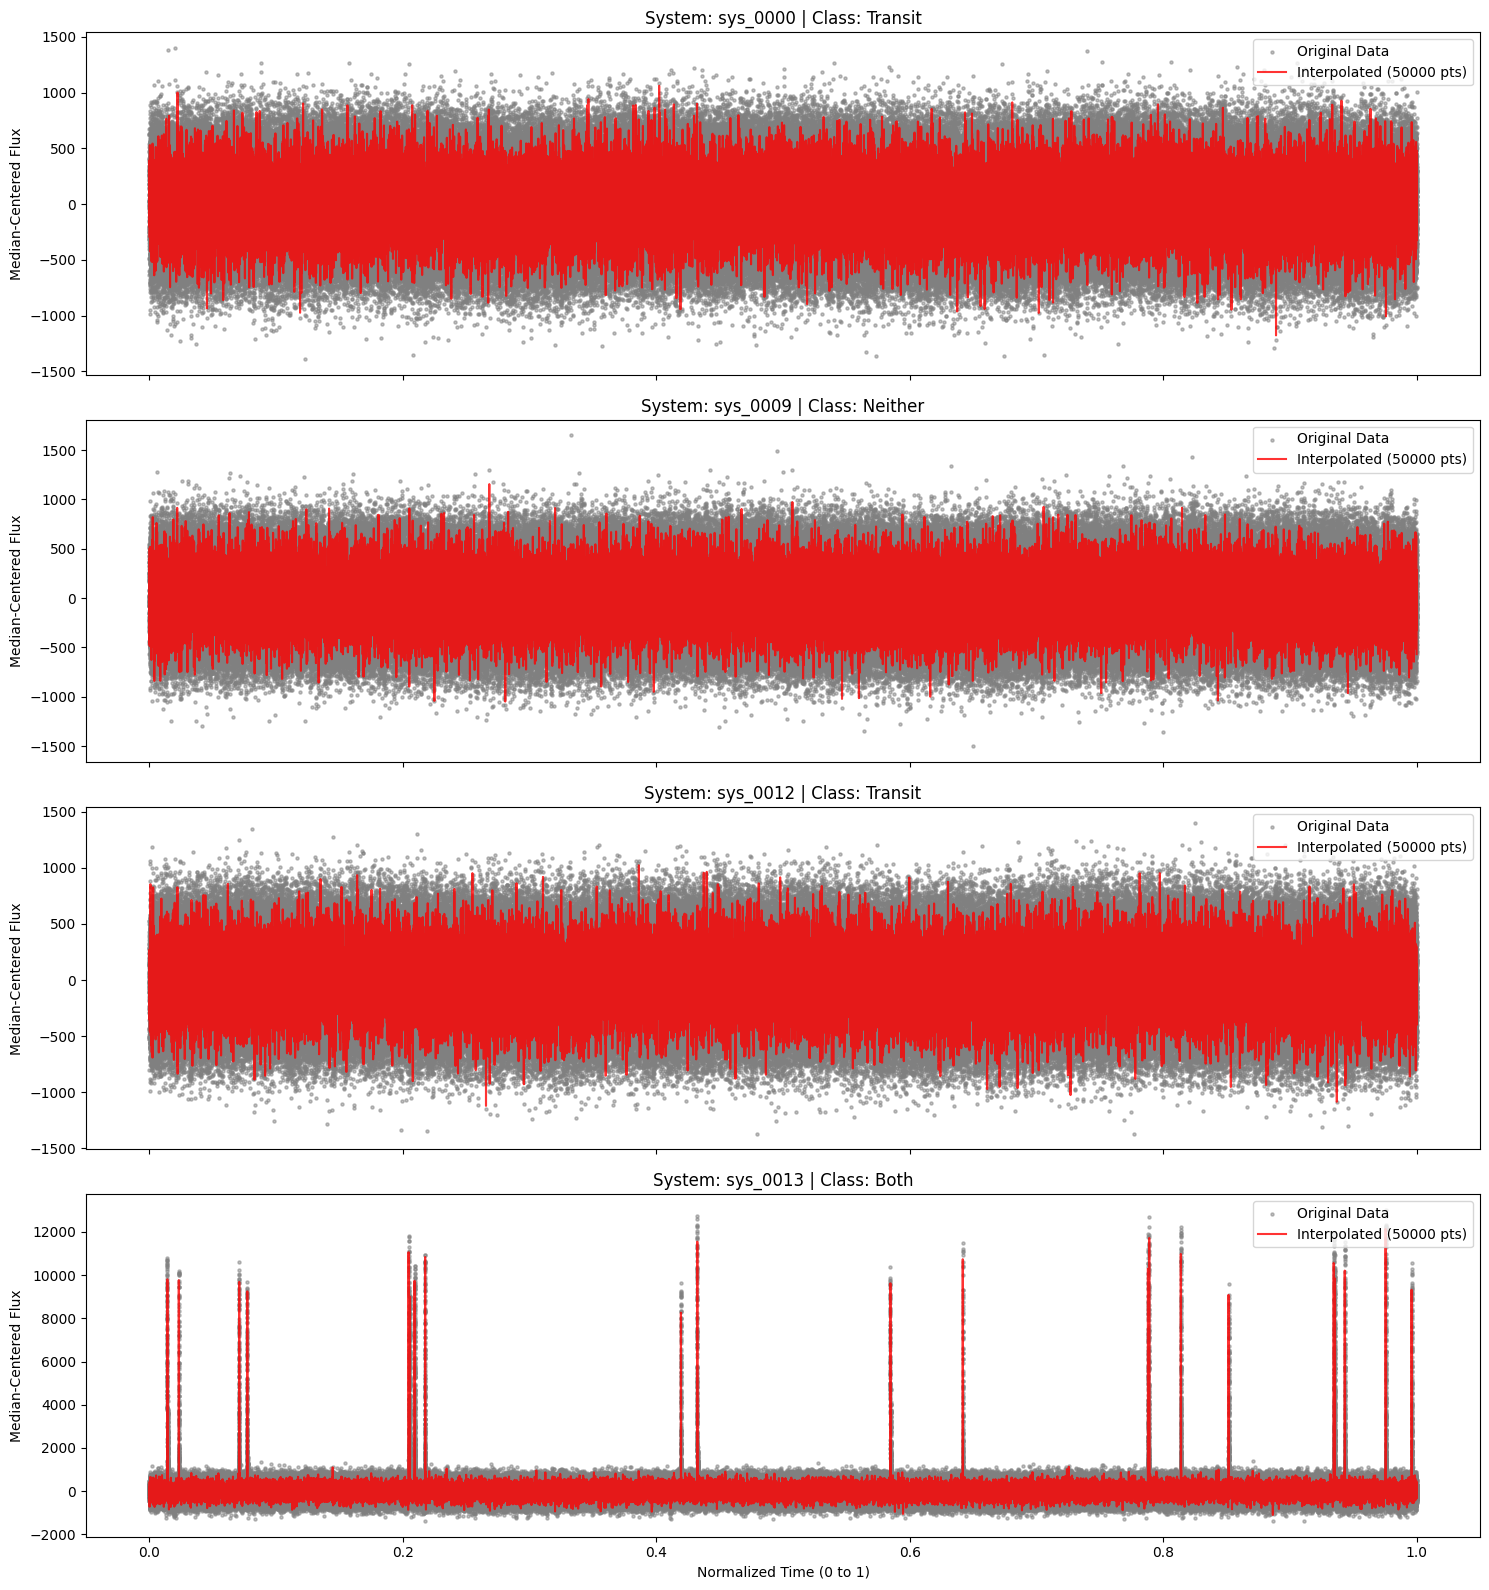

In [29]:
build_prebaked_dataset(df, max_length=50_000, save_path="cnn_dataset.pt", plot_samples=4)

In [53]:
class LightCurveCNN(nn.Module):
    def __init__(self, input_length=50_000):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(4),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            flat_size = self.convs(dummy).numel()
        print(f"Flattened size: {flat_size}")

        self.shared_fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        # Two independent heads — one per binary question
        self.head_flare   = nn.Linear(64, 1)  # has flare?
        self.head_transit = nn.Linear(64, 1)  # has transit?

    def forward(self, x):
        x = self.convs(x)
        x = x.flatten(1)
        x = self.shared_fc(x)
        return self.head_flare(x).squeeze(1), self.head_transit(x).squeeze(1)

In [54]:
from torch.utils.data import TensorDataset, DataLoader

def get_dataloaders(save_path, batch_size=32):
    data = torch.load(save_path)
    X, y = data['X'], data['y']

    # Decompose 4-class label into two binary labels
    # 0=Neither, 1=Flare, 2=Transit, 3=Both
    has_flare   = ((y == 1) | (y == 3)).float()
    has_transit = ((y == 2) | (y == 3)).float()
    y_multilabel = torch.stack([has_flare, has_transit], dim=1)  # (N, 2)

    train_idx = int(0.8 * len(X))
    train_ds = TensorDataset(X[:train_idx], y_multilabel[:train_idx])
    val_ds   = TensorDataset(X[train_idx:], y_multilabel[train_idx:])

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), \
           DataLoader(val_ds,   batch_size=batch_size)

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        # Add evaluation logic here (e.g., accuracy calculation)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

In [55]:
import time

def run_training_pipeline(save_path="cnn_dataset.pt", epochs=10):
    start_total = time.time()
    label_names = {0: "Neither", 1: "Flare", 2: "Transit", 3: "Both"}

    print("--- 1. Loading Prebaked Data ---")
    train_loader, val_loader = get_dataloaders(save_path)

    model = LightCurveCNN(input_length=50_000, num_classes=4)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"--- 2. Starting Training on {device} ---")
    print(f"Dataset size: {len(train_loader.dataset)} samples")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0

        for i, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if i % 10 == 0:
                print(f"  Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # --- Validation ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        class_correct = {i: 0 for i in range(4)}
        class_total   = {i: 0 for i in range(4)}
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                val_loss += criterion(out, y).item()
                preds = out.argmax(dim=1)
                correct += (preds == y).sum().item()
                total   += len(y)
                for c in range(4):
                    mask = y == c
                    class_correct[c] += (preds[mask] == y[mask]).sum().item()
                    class_total[c]   += mask.sum().item()

        epoch_time = time.time() - epoch_start
        print(f"\nEpoch {epoch+1}/{epochs} | {epoch_time:.1f}s | "
              f"Train Loss: {running_loss/len(train_loader):.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f} | "
              f"Val Acc: {100*correct/total:.1f}%")
        for c in range(4):
            if class_total[c] > 0:
                print(f"  {label_names[c]:8s}: {class_correct[c]}/{class_total[c]} "
                      f"= {100*class_correct[c]/class_total[c]:.1f}%")

    torch.save(model.state_dict(), "cnn_model.pt")
    print(f"\nModel saved to cnn_model.pt")
    print(f"Total time: {(time.time()-start_total)/60:.2f} minutes")
    return model, val_loader, device

# Execute
model, val_loader, device = run_training_pipeline()

--- 1. Loading Prebaked Data ---


TypeError: LightCurveCNN.__init__() got an unexpected keyword argument 'num_classes'

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_length': 50_000,
    'num_classes': 4,
}, "cnn_checkpoint.pt")
print("Saved to cnn_checkpoint.pt")

  Neither  (class 0): 369 samples (24.8%)
  Flare    (class 1): 374 samples (25.2%)
  Transit  (class 2): 359 samples (24.2%)
  Both     (class 3): 383 samples (25.8%)


In [ ]:
def evaluate_model(checkpoint_path="cnn_checkpoint.pt", data_path="cnn_dataset.pt"):
    # Load model
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = LightCurveCNN(input_length=checkpoint['input_length'], 
                          num_classes=checkpoint['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Load full dataset
    data = torch.load(data_path, map_location="cpu")
    X, y, ids = data['X'], data['y'], data['ids']
    
    label_names = {0: "Neither", 1: "Flare", 2: "Transit", 3: "Both"}
    
    # Run inference on every sample
    with torch.no_grad():
        logits = model(X)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

    correct = (preds == y).sum().item()
    print(f"Overall accuracy: {correct}/{len(y)} = {100*correct/len(y):.1f}%\n")

    # Per-class breakdown
    print("Per-class accuracy:")
    for c in range(4):
        mask = y == c
        n = mask.sum().item()
        n_correct = (preds[mask] == y[mask]).sum().item()
        print(f"  {label_names[c]:8s}: {n_correct}/{n} = {100*n_correct/n:.1f}%")

    # Confusion matrix
    print("\nConfusion matrix (rows=true, cols=predicted):")
    print(f"{'':12s}", end="")
    for c in range(4):
        print(f"{label_names[c]:10s}", end="")
    print()
    for true_c in range(4):
        print(f"{label_names[true_c]:12s}", end="")
        for pred_c in range(4):
            mask = (y == true_c) & (preds == pred_c)
            print(f"{mask.sum().item():10d}", end="")
        print()

    # Show 5 random examples
    print("\nRandom examples:")
    print(f"{'sys_id':12s} {'True':10s} {'Pred':10s} {'Confidence':10s}")
    idx = torch.randperm(len(y))[:10]
    for i in idx:
        true_label = label_names[y[i].item()]
        pred_label = label_names[preds[i].item()]
        conf = probs[i].max().item()
        match = "✓" if preds[i] == y[i] else "✗"
        print(f"{ids[i]:12s} {true_label:10s} {pred_label:10s} {conf:.2f}  {match}")

evaluate_model()